## Lab Week 11 Part 3: Data Analysis

This notebook reads the thorium-source and fiestaware-source CSV files, computes summary statistics, plots the histograms of interval counts, plots total counts vs. absorber thickness with Poisson uncertainties, and estimates the absorption coefficients for tungsten and aluminum.

### 1. Read Data

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# File paths
base = Path(".")
thorium_files = {
    0.0: base / "thoriumsource0.csv",
    1.0: base / "thoriumsource1.csv",
    2.0: base / "thoriumsource2.csv",
    3.0: base / "thoriumsource3.csv",
}

fiesta_files = {
    0.0: base / "fiestasource0.csv",
    0.3: base / "fiestasource1.csv",
    0.9: base / "fiestasource2.csv",
    1.8: base / "fiestasource3.csv",
    2.4: base / "fiestasource4.csv",
}

thorium_data = {x: pd.read_csv(path) for x, path in thorium_files.items()}
fiesta_data = {x: pd.read_csv(path) for x, path in fiesta_files.items()}

print("Loaded thorium files:")
for x, df in thorium_data.items():
    print(f"  W thickness = {x:.1f} cm -> shape = {df.shape}")

print("\nLoaded fiestaware files:")
for x, df in fiesta_data.items():
    print(f"  Al thickness = {x:.1f} cm -> shape = {df.shape}")

Loaded thorium files:
  W thickness = 0.0 cm -> shape = (13, 4)
  W thickness = 1.0 cm -> shape = (13, 4)
  W thickness = 2.0 cm -> shape = (13, 4)
  W thickness = 3.0 cm -> shape = (13, 4)

Loaded fiestaware files:
  Al thickness = 0.0 cm -> shape = (13, 4)
  Al thickness = 0.3 cm -> shape = (13, 4)
  Al thickness = 0.9 cm -> shape = (13, 4)
  Al thickness = 1.8 cm -> shape = (13, 4)
  Al thickness = 2.4 cm -> shape = (13, 4)


### 2. Histograms of Interval Counts

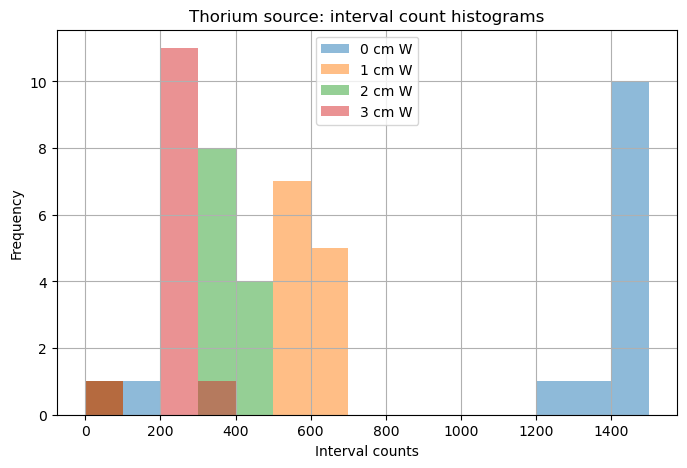

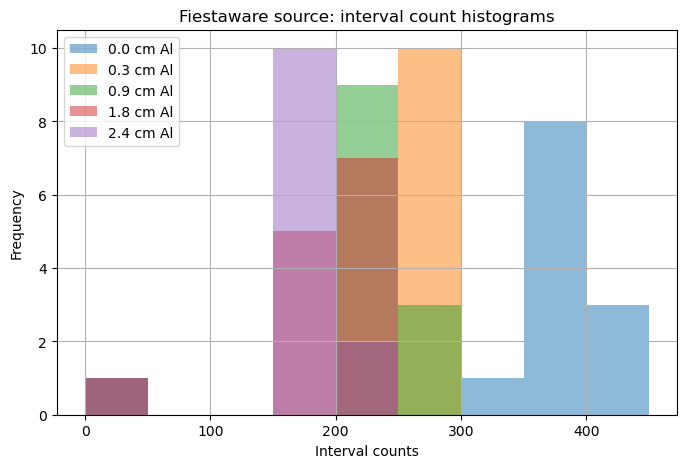

In [24]:
# Thorium histograms on one graph
plt.figure()
bins = np.arange(0, max(df["Total_Counts"].max() for df in thorium_data.values()) + 100, 100)

for thickness, df in thorium_data.items():
    plt.hist(df["Total_Counts"], bins=bins, alpha=0.5, label=f"{thickness:.0f} cm W")

plt.xlabel("Interval counts")
plt.ylabel("Frequency")
plt.title("Thorium source: interval count histograms")
plt.legend()
plt.show()

# Fiestaware histograms on one graph
plt.figure()
bins = np.arange(0, max(df["Total_Counts"].max() for df in fiesta_data.values()) + 50, 50)

for thickness, df in fiesta_data.items():
    plt.hist(df["Total_Counts"], bins=bins, alpha=0.5, label=f"{thickness:.1f} cm Al")

plt.xlabel("Interval counts")
plt.ylabel("Frequency")
plt.title("Fiestaware source: interval count histograms")
plt.legend()
plt.show()

In [25]:
### Measured vs theoretical statistics

def summarize_measurements(data_dict, absorber_name):
    rows = []
    for thickness, df in data_dict.items():
        cps_mean = df["CPS"].mean()
        cps_std = df["CPS"].std(ddof=1)

        counts_mean = df["Total_Counts"].mean()
        counts_std = df["Total_Counts"].std(ddof=1)

        theoretical_counts_sigma = np.sqrt(counts_mean)
        theoretical_cps_sigma = np.sqrt(counts_mean) / 10.0

        total_counts = df["Total_Counts"].sum()
        total_unc = np.sqrt(total_counts)

        rows.append({
            "absorber": absorber_name,
            "thickness_cm": thickness,
            "mean_CPS": cps_mean,
            "std_CPS": cps_std,
            "mean_interval_counts": counts_mean,
            "std_interval_counts": counts_std,
            "theory_sigma_counts": theoretical_counts_sigma,
            "theory_sigma_CPS": theoretical_cps_sigma,
            "total_counts_120s": total_counts,
            "unc_total_counts": total_unc,
        })

    out = pd.DataFrame(rows).sort_values("thickness_cm").reset_index(drop=True)
    return out

thorium_summary = summarize_measurements(thorium_data, "Tungsten")
fiesta_summary = summarize_measurements(fiesta_data, "Aluminum")

def compare_to_counting_statistics(summary_df, label):
    out = summary_df[[
        "thickness_cm",
        "mean_interval_counts",
        "std_interval_counts",
        "theory_sigma_counts",
        "mean_CPS",
        "std_CPS",
        "theory_sigma_CPS"
    ]].copy()

    out["counts_std / theory"] = out["std_interval_counts"] / out["theory_sigma_counts"]
    out["CPS_std / theory"] = out["std_CPS"] / out["theory_sigma_CPS"]

    print(label)
    display(out)

compare_to_counting_statistics(thorium_summary, "Thorium / tungsten: measured vs theoretical spread")
compare_to_counting_statistics(fiesta_summary, "Fiestaware / aluminum: measured vs theoretical spread")

Thorium / tungsten: measured vs theoretical spread


,thickness_cm,mean_interval_counts,std_interval_counts,theory_sigma_counts,mean_CPS,std_CPS,theory_sigma_CPS,counts_std / theory,CPS_std / theory
0,0.0,1327.923077,350.279760,36.440679,177.384615,9.622356,3.644068,9.612328,2.640554
1,1.0,559.923077,147.110764,23.662694,77.846154,6.643871,2.366269,6.216991,2.807741
2,2.0,361.000000,97.464523,19.000000,50.384615,7.610721,1.900000,5.129712,4.005643
3,3.0,259.692308,65.412008,16.114972,36.461538,6.213096,1.611497,4.059083,3.855481


Fiestaware / aluminum: measured vs theoretical spread


,thickness_cm,mean_interval_counts,std_interval_counts,theory_sigma_counts,mean_CPS,std_CPS,theory_sigma_CPS,counts_std / theory,CPS_std / theory
0,0.0,360.769231,98.142035,18.993926,49.461538,8.422345,1.899393,5.167022,4.434231
1,0.3,245.538462,64.221771,15.669667,35.538462,5.332532,1.566967,4.098477,3.403092
2,0.9,220.615385,57.383997,14.853127,29.461538,7.389355,1.485313,3.863429,4.974949
3,1.8,187.000000,50.479369,13.674794,25.692308,4.423133,1.367479,3.691417,3.234515
4,2.4,176.692308,47.221790,13.292566,22.692308,3.682948,1.329257,3.552496,2.770682


### 2. How do the mean (mu) and standard deviation (sigma) compare?
- The standard deviation is quite large, being approximately 25% of the mean for most data sets.

### 2a. How do the measured standard deviations compare to counting-statistics expectations?
- For radioactive counting over fixed time intervals, the expected uncertainty is approximately Poisson, so: sigma_N = sqrt(mu_N).

- The measured standard deviations are generally comparable in magnitude to this prediction, but they are not exactly equal. Differences from the ideal Poisson prediction can come from finite sample size, source-detector geometry, electronics dead time, background variation, and the fact that real radioactive spectra are not perfectly monoenergetic.

### 2b. What trend is seen as absorber thickness increases?
- The count rate and total detected counts both decrease as absorber thickness increases. This is the expected attenuation trend: more shielding causes fewer detected counts.

### 3. Total Count Plot with Uncertainties

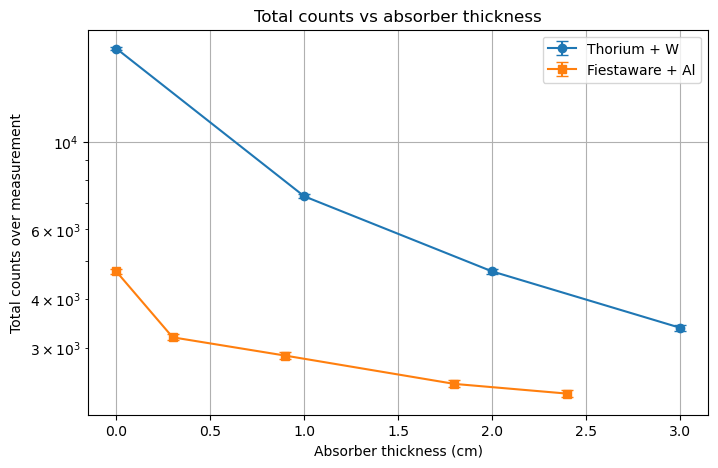

In [26]:
thor_x = thorium_summary["thickness_cm"].to_numpy()
thor_N = thorium_summary["total_counts_120s"].to_numpy()
thor_dN = thorium_summary["unc_total_counts"].to_numpy()

fie_x = fiesta_summary["thickness_cm"].to_numpy()
fie_N = fiesta_summary["total_counts_120s"].to_numpy()
fie_dN = fiesta_summary["unc_total_counts"].to_numpy()

plt.figure()
plt.errorbar(thor_x, thor_N, yerr=thor_dN, marker="o", capsize=4, label="Thorium + W")
plt.errorbar(fie_x, fie_N, yerr=fie_dN, marker="s", capsize=4, label="Fiestaware + Al")
plt.yscale("log")
plt.xlabel("Absorber thickness (cm)")
plt.ylabel("Total counts over measurement")
plt.title("Total counts vs absorber thickness")
plt.legend()
plt.show()

## 4–5. Absorption Coefficients
Absorption is modeled as: 

N(x) = N_0 * exp(-mu * x)

where N is the number of counts, N_0 is the number of counts with no absorber, x is the absorber thickness, and mu is the absorption coefficient. We estimate the absorption coefficient by fitting:

ln N = ln N_0 - mu * x

using a weighted linear fit. The uncertainty in a measured total count is taken to be Poisson:

sigma_N = sqrt(N)

So the uncertainty in log-space is approximated by:

sigma_(ln N) = sigma_N / N = 1 / sqrt(N)

In [27]:
def fit_absorption(thickness_cm, total_counts):
    x = np.asarray(thickness_cm, dtype=float)
    N = np.asarray(total_counts, dtype=float)

    y = np.log(N)
    sigma_y = 1 / np.sqrt(N)

    # Weighted fit: numpy.polyfit uses weights on residuals, so w = 1/sigma
    coeffs, cov = np.polyfit(x, y, deg=1, w=1/sigma_y, cov=True)
    slope, intercept = coeffs
    mu = -slope
    mu_unc = np.sqrt(cov[0, 0])

    return {
        "slope": slope,
        "intercept": intercept,
        "mu": mu,
        "mu_unc": mu_unc,
        "cov": cov
    }

thor_fit = fit_absorption(thor_x, thor_N)
fie_fit = fit_absorption(fie_x, fie_N)

print(f"Tungsten absorption coefficient mu = {thor_fit['mu']:.4f} ± {thor_fit['mu_unc']:.4f} cm^-1")
print(f"Aluminum absorption coefficient mu = {fie_fit['mu']:.4f} ± {fie_fit['mu_unc']:.4f} cm^-1")

Tungsten absorption coefficient mu = 0.5905 ± 0.0889 cm^-1
Aluminum absorption coefficient mu = 0.2777 ± 0.0789 cm^-1


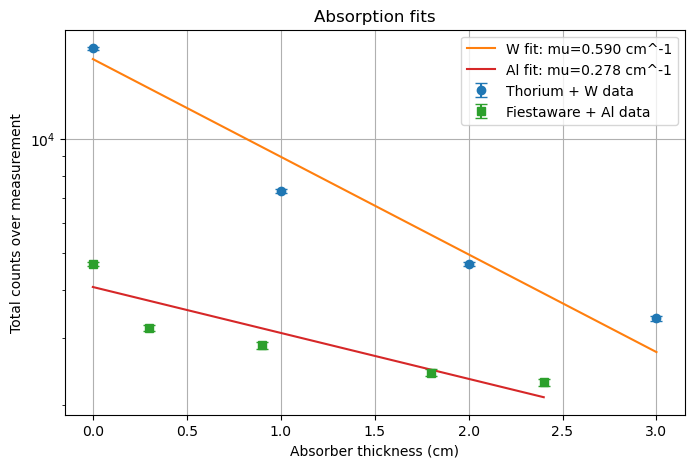

In [28]:
# Plot data plus fitted curves
x_thor_fit = np.linspace(thor_x.min(), thor_x.max(), 200)
y_thor_fit = np.exp(thor_fit["intercept"] - thor_fit["mu"] * x_thor_fit)

x_fie_fit = np.linspace(fie_x.min(), fie_x.max(), 200)
y_fie_fit = np.exp(fie_fit["intercept"] - fie_fit["mu"] * x_fie_fit)

plt.figure()
plt.errorbar(thor_x, thor_N, yerr=thor_dN, marker="o", capsize=4, linestyle="none", label="Thorium + W data")
plt.plot(x_thor_fit, y_thor_fit, label=f"W fit: mu={thor_fit['mu']:.3f} cm^-1")

plt.errorbar(fie_x, fie_N, yerr=fie_dN, marker="s", capsize=4, linestyle="none", label="Fiestaware + Al data")
plt.plot(x_fie_fit, y_fie_fit, label=f"Al fit: mu={fie_fit['mu']:.3f} cm^-1")

plt.yscale("log")
plt.xlabel("Absorber thickness (cm)")
plt.ylabel("Total counts over measurement")
plt.title("Absorption fits")
plt.legend()
plt.show()

### 4. Do the graphs follow the expected trend?
Yes, on a semilog plot, the data decreases approximately linearly with absorber thickness, which is consistent with exponential attenuation.

### 5. Should the measured absorption coefficients be the same?
No, the absorption coefficients should not generally be the same because:
- the absorber materials are different (tungsten vs aluminum)
- the photon energy spectra from the two sources are different
- attenuation depends strongly on photon energy and atomic number
- scattering, background, finite geometry, and detector response can also affect the measured effective coefficient

So even if both data sets show exponential attenuation, the fitted mu values are not expected to match. Comparing the two values, tungsten has an attenuation cofficient more than double that of aluminum, which is expected as it is higher Z so has strong photoelectric + compton attenuation of gammas. Note that although the primary source of emitted radiation from both fiestaware (uranium oxide) and thorium are alpha particles, the radiation incident on the detector is primarily gamma from the decay chains as there are 5 cm of air / absorber separating the source from the detector, so all alphas (and betas from decay chains) would have been attenuated.